# Research Questions (1.1)

## What type of delays are occuring most at the airports?
For airport delays in general


# Data Cleaning

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px


## Airport Traffic
Importing dataset

In [ ]:
df_AT = pd.read_excel("datasets/AirportTraffic.xlsx")
df_AAD = pd.read_excel("datasets/AA_ATFM_Delay.xlsx")
df_AP = pd.read_excel("datasets/Airports_Punctuality.xlsx")
df_AID= pd.read_excel("datasets/Airport_IATA_delays_airline_reported.xlsx")
df_PDD = pd.read_excel("datasets/Primary_departure_Delay_Causes_AP.xlsx")
df_FPD = pd.read_excel("datasets/Flight_Punctuality_Distribution.xlsx")
df_Ageo = pd.read_csv("datasets/Airport_Geo2.csv", quoting=3, on_bad_lines="skip")

Find top 20 airports by total flights and create a new dataframe with key data

In [57]:
df_top20 = (
    df_AT.groupby("APT_ICAO")[["FLT_TOT_1", "FLT_DEP_1", "FLT_ARR_1"]] #Group by airport code
    .sum().sort_values(by="FLT_TOT_1",ascending=False) #Sum the values for each code of the 3 columns indicated
    .head(20).reset_index()) #Change "20" to change the number of airports analysed
# Adding airport's city name and state from original dataset
df_top20 = (df_top20.merge(df_AT[["APT_ICAO", "APT_NAME", "STATE_NAME"]]
                           .drop_duplicates(), on="APT_ICAO", how="left"))
df_top20.head(20)


airports_code_list = df_top20["APT_ICAO"].unique().tolist()

Mean airport traffic every month

In [22]:
df_AT_top20 = df_AT[df_AT["APT_ICAO"].isin(df_top20["APT_ICAO"])]

# Calculating the mean for every month
df_AT_top20_month = df_AT_top20.groupby(["APT_ICAO", "YEAR", "MONTH_NUM"])[["FLT_TOT_1", "FLT_DEP_1", "FLT_ARR_1"]].mean().reset_index()
df_AT_top20_month = df_AT_top20_month.rename(columns={
    "FLT_TOT_1": "FLT_MEAN",
    "FLT_DEP_1": "FLT_MEAN_DEP",
    "FLT_ARR_1": "FLT_MEAN_ARR"
})
df_AT_top20_month.to_csv("datasets_rq4/df_AT_top20_month.csv")


# Airport Punctionality

In [12]:
airport_map = {
    "LTFM": "Istanbul",
    "EHAM": "Amsterdam",
    "EGLL": "London Heathrow",
    "LFPG": "Paris Charles de Gaulle",
    "EDDF": "Frankfurt",
    "LEMD": "Madrid Barajas",
    "LEBL": "Barcelona",
    "EDDM": "Munich",
    "LIRF": "Rome Fiumicino",
    "EGKK": "London Gatwick",
    "LSZH": "Zurich",
    "LGAV": "Athens",
    "EIDW": "Dublin",
    "LOWW": "Vienna",
    "LEPA": "Palma de Mallorca",
    "EKCH": "Copenhagen",
    "LPPT": "Lisbon",
    "LTFJ": "Istanbul Sabiha Gokcen",
    "LTAI": "Antalya",
    "ENGM": "Oslo"
}

top20_codes = [airport_map[a] for a in df_top20['APT_ICAO'] if a in airport_map]
df_AP_top20 = df_AP[df_AP['Airport'].isin(top20_codes)]

name_to_icao = {name: icao for icao, name in airport_map.items()}
icao_codes = df_AP_top20["Airport"].map(name_to_icao)
df_AP_top20.insert(loc=2, column="APT_ICAO", value=df_AP_top20["Airport"].map(name_to_icao))

df_AP_top20

,Date,Airport,APT_ICAO,Departure Punctuality %,Arrival Punctuality %,Avg Departure Schedule Delay,Avg Arrival Schedule Delay,Avg Departure - Arrival Schedule Delay,Operated Schedules %
1367,2022-01-01,Frankfurt,EDDF,0.818898,0.804217,13.043920,13.426908,-0.382988,0.922170
1368,2022-01-02,Frankfurt,EDDF,0.707216,0.713389,17.652062,18.506590,-0.854528,0.946463
1369,2022-01-03,Frankfurt,EDDF,0.738938,0.755991,16.235140,13.956209,2.278931,0.952183
1370,2022-01-04,Frankfurt,EDDF,0.630542,0.725962,16.605624,14.621955,1.983669,0.953811
1371,2022-01-05,Frankfurt,EDDF,0.782816,0.821951,10.382379,9.699187,0.683192,0.946785
...,...,...,...,...,...,...,...,...,...
43735,2025-09-24,Istanbul,LTFM,0.840440,0.831309,8.972031,11.150967,-2.178936,0.922894
43736,2025-09-25,Istanbul,LTFM,0.794157,0.843750,11.858544,8.783967,3.074576,0.930314
43737,2025-09-26,Istanbul,LTFM,0.713147,0.770039,15.778220,13.545795,2.232425,0.938824
43738,2025-09-27,Istanbul,LTFM,0.748021,0.782377,17.316623,13.748999,3.567624,0.948931


## Primary Delay Causes
Dataset contains sum of total delay per main category (airline, airport, En Route, Miscellaneous, Government, Weather) per airport


In [56]:
df_PDD_TOP20 = (
    df_PDD[df_PDD["APT_ICAO"].isin(airports_code_list)]
)

df_PDD_summary = (
    df_PDD_TOP20
    .groupby(["Year","APT_ICAO"], as_index=False)
    .agg({
        "Airline": "sum",
        "En_Route": "sum",
        "Miscellaneous": "sum",
        "Government": "sum",
        "Weather": "sum",
        
    })
    .sort_values(by="APT_ICAO", ascending=False)   
    .reset_index(drop=True)
)
display(df_PDD_summary)
df_PDD_summary.to_csv("df_PDD_summary.csv", index=False)

,Year,APT_ICAO,Airline,En_Route,Miscellaneous,Government,Weather
0,2024,UGTB,18063,3687,3648,6808,2169
1,2023,UGTB,15431,611,1592,6486,3089
2,2023,UDYZ,11761,3068,5050,303,213
3,2024,UDYZ,13071,7319,2579,574,337
4,2024,LZIB,7172,9053,746,519,1693
...,...,...,...,...,...,...,...
568,2023,EBBR,248805,136916,31811,37064,27416
569,2024,EBAW,1935,1978,141,44,305
570,2023,EBAW,1150,1684,191,43,519
571,2024,BIKF,18981,1433,4786,1669,9713


C:\Users\vermeej\AppData\Local\Temp\ipykernel_23040\2086170770.py:9: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



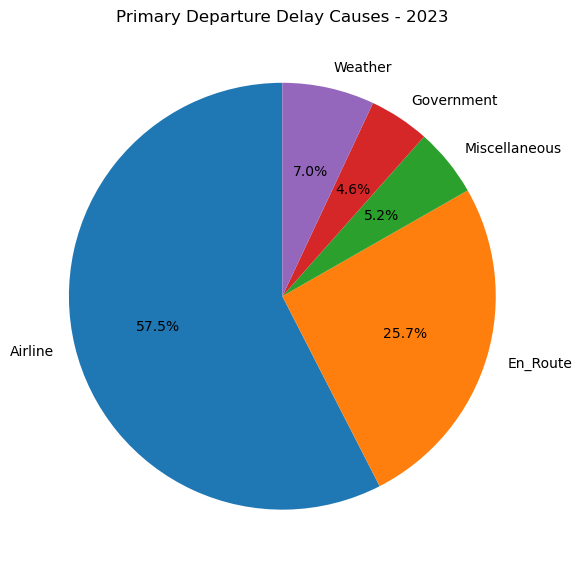

C:\Users\vermeej\AppData\Local\Temp\ipykernel_23040\2086170770.py:9: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



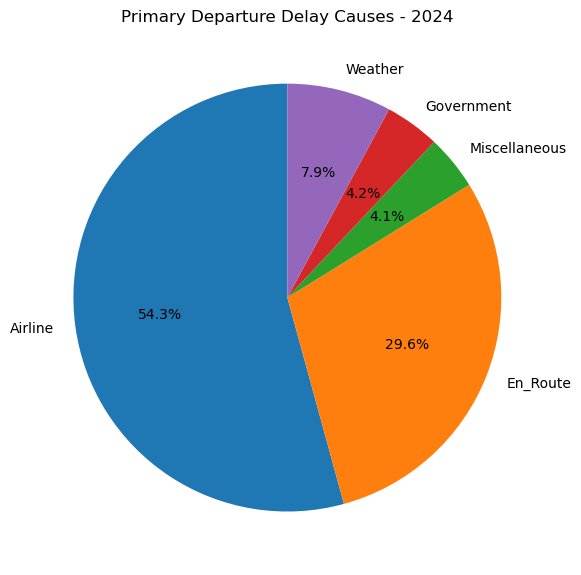

In [53]:
# Delay cause columns
causes = ["Airline", "En_Route", "Miscellaneous", "Government", "Weather"]

# Pie charts for each year
for yr in ["2023", "2024"]:
    data = (
        df_PDD_summary[df_PDD_summary["Year"].astype(str) == yr][causes]
        .sum()
        .fillna(0)
    )

    plt.figure(figsize=(6, 6))
    plt.pie(data.values, labels=causes, autopct="%1.1f%%", startangle=90)
    plt.title(f"Primary Departure Delay Causes - {yr}")
    plt.tight_layout()
    plt.show()


## Airport IATA delays
Year lobt = Year of the Last Off-Block Time (LOBT) \
TD = Total Delay (minutes) \
TF = Total Flights affected \
Total Flights Period = total number of flights in that airport/period \
ADM = Average Delay per Movement = TD/Total Flight Period  (minutes per total flight)
Total Delay Period = Total delay minutes (all causes) for the period \
PD = Proportion of delay = (TD / Total Delay Period)*100
Delay rate = TF / Total flight period


In [80]:
# Filter the delay dataset for only the top 20 airports
df_AID_TOP20 = df_AID[df_AID["APT_ICAO"].isin(airports_code_list)].copy()

# 1) Aggregate airport + label 
df_delay_types = (
    df_AID_TOP20
    .groupby(["APT_ICAO", "Label"], as_index=False)["TD"]
    .sum()
)

# each label different colour
unique_labels = df_delay_types["Label"].unique()
color_map = {label: px.colors.qualitative.Dark24[i % len(px.colors.qualitative.Dark24)]
             for i, label in enumerate(unique_labels)}

# Ploty bar chart - Stacked
fig = px.bar(
    df_delay_types,
    x="APT_ICAO",
    y="TD",
    color="Label",
    color_discrete_map=color_map,
    title="Total Delay by Airport and Delay Reason",
    labels={
        "APT_ICAO": "Airport (ICAO Code)",
        "TD": "Total Delay (minutes)",
        "Label": "Delay Reason"
    },
)

fig.update_layout(
    barmode="stack",
    xaxis_title="Airport (APT_ICAO)",
    yaxis_title="Total Delay (minutes)",
    legend_title="Delay Reasons",
    xaxis=dict(showgrid=False),
    yaxis=dict(gridcolor="lightgray"),
    width=950,
    height=600,
    legend=dict(
        title_font_size=14,
        font_size=12,
    )
)

fig.show()

In [ ]:
# Filter the delay dataset for only the top 20 airports
df_AID_TOP20 = df_AID[df_AID["APT_ICAO"].isin(airports_code_list)].copy()

# Calculate delay ratio as percentage
df_AID_TOP20["Delay_Ratio"] = (df_AID_TOP20["TF"] / df_AID_TOP20["Total_Flights_Period"]) * 100

# Provide key insights per year per month per airport
df_AID_TOP20_YMA = (
    df_AID_TOP20
    .groupby(["Year_Lobt","Month_Lobt","APT_ICAO","Total_Flights_Period"], as_index=False)
    .agg({
        "TD": "sum",
        "TF": "sum",
        "adm": "sum",
        "pd": "mean",
        "Delay_Ratio": "mean" 
    })
    .sort_values(by="TF", ascending=False)
    .rename(columns={
        "TD": "Total Delay (TD)",
        "TF": "Total Flights (TF)",
        "adm": "Avg Delay per Movement (in min)",
        "pd": "Avg Proportion of Delay (%)",
        "Delay_Rate": "Avg Delay Ratio (%)"
    })
    .reset_index(drop=True)
)

df_AID_TOP20_YMA.to_csv("datasets_rq4/df_AID_TOP20_YMA.csv")
display(df_AID_TOP20_YMA)


,Year_Lobt,Month_Lobt,APT_ICAO,Total_Flights_Period,Total Delay (TD),Total Flights (TF),Avg Delay per Movement (in min),Avg Proportion of Delay (%),Delay_Ratio
0,2024,July,EDDF,14380,295785,25288,20.569193,4.243149,10.344433
1,2024,August,EDDF,14361,242797,23770,16.906692,4.492451,9.736337
2,2024,September,EDDF,14179,213238,23435,15.039001,4.513545,9.722332
3,2023,August,EDDF,14135,291567,21990,20.627308,4.496111,9.151252
4,2023,July,EDDF,13967,246893,21909,17.676881,4.288736,9.227212
...,...,...,...,...,...,...,...,...,...
474,2024,March,LTAI,2289,10483,942,4.579729,3.955655,2.420785
475,2023,November,LTAI,939,10645,865,11.336528,2.820361,5.418781
476,2024,February,LTAI,1673,8567,826,5.120741,4.072252,2.904258
477,2024,April,LTFJ,218,5679,128,26.050459,5.540866,3.453859


In [16]:
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

In [54]:
df_AID_TOP20_YMA = df_AID_TOP20_YMA.rename(columns={
    "Delay_Ratio": "Avg Delay Ratio (%)"
})

# month order
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# Aggregate dataframe for line chart
df_avg = (
    df_AID_TOP20_YMA
    .groupby(["Year_Lobt", "Month_Lobt", "APT_ICAO"], as_index=False)[["Avg Delay Ratio (%)"]]
    .mean()
)

# Month lobt follows chronological order
df_avg["Month_Lobt"] = pd.Categorical(df_avg["Month_Lobt"], categories=month_order, ordered=True)

# all_airport order
df_all_avg = (
    df_avg.groupby(["Year_Lobt", "Month_Lobt"], as_index=False)[["Avg Delay Ratio (%)"]]
    .mean()
)
df_all_avg["APT_ICAO"] = "ALL"

# Combine & sort
df_plot = pd.concat([df_avg, df_all_avg], ignore_index=True)
df_plot = df_plot.sort_values(["APT_ICAO", "Year_Lobt", "Month_Lobt"])

# Plot function with airport filter
def plot_delay_ratio(selected_airport="ALL"):
    if selected_airport == "ALL":
        dff = df_plot[df_plot["APT_ICAO"] == "ALL"]
        title = "Average Delay Ratio by Month — All Airports"
    else:
        dff = df_plot[df_plot["APT_ICAO"] == selected_airport]
        title = f"Average Delay Ratio by Month — {selected_airport}"
    
    # Plot one line per year
    fig = px.line(
        dff,
        x="Month_Lobt",
        y="Avg Delay Ratio (%)",
        color="Year_Lobt",
        markers=True,
        line_shape="linear", 
        title=title,
        labels={
            "Month_Lobt": "Month",
            "Avg Delay Ratio (%)": "Average Delay Ratio (%)",
            "Year_Lobt": "Year"
        }
    )

    fig.update_layout(
        template="plotly_white",
        xaxis=dict(categoryorder="array", categoryarray=month_order),
        yaxis_title="Average Delay Ratio (%)",
        hovermode="x unified",
        xaxis_tickangle=-45,
        legend_title="Year"
    )

    fig.show()

# Dropdown for airport selection
airport_list = ["ALL"] + sorted(df_AID_TOP20_YMA["APT_ICAO"].unique())

dropdown = widgets.Dropdown(
    options=airport_list,
    value="ALL",
    description="Airport:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='40%')
)

widgets.interact(plot_delay_ratio, selected_airport=dropdown)

C:\Users\vermeej\AppData\Local\Temp\ipykernel_23040\759221278.py:23: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



interactive(children=(Dropdown(description='Airport:', layout=Layout(width='40%'), options=('ALL', 'EDDF', 'ED…

<function __main__.plot_delay_ratio(selected_airport='ALL')>